# Appendix A: Simulations Code and Parameters

This notebook implements and run the simulations presented in the paper.

## Preamble

### Imports 

In [1]:
import warnings
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

from scipy.signal import detrend

warnings.filterwarnings("ignore")
pal = sns.color_palette("icefire", 3)

### Simulation Code

In [2]:
class Agent(object):
    """
    A learning agent.
    """

    def __init__(
        self, name, init_belief, random_choice_prob=0, payoffs_type="Increasing"
    ):
        self.name = name
        self.current_beliefs = init_belief
        self.past_beliefs = []
        self.random_choice_prob = random_choice_prob
        self.past_payoffs = []
        self.current_round = 0
        self.payoffs_type = payoffs_type

    def __repr__(self):
        return f"""Agent {self.name} at Round {self.current_round}.
        Current Beliefs: {self.current_beliefs}
        """

    def compute_utility(self, prospects):
        """
        Compute the utility of a set of prospects, based on current beliefs
        """
        utility = np.dot(prospects, self.current_beliefs)
        return utility

    def compute_choice_probabilities(self, prospects):
        """
        Compute the choice probability of a set of prospects, based on current beliefs
        """
        X = self.compute_utility(prospects)
        eXB = np.exp(X)
        return (eXB / eXB.sum(0)).flatten(order="F")

    def choose_prospect(self, prospects, choice_strategy="Positive"):
        """
        Chooses a prospect among a set, based on a specified choice strategy 
        ('Positive' or 'Random').
        """
        n_options = prospects.shape[0]
        options = np.arange(n_options)
        if choice_strategy == "Positive":
            p = self.compute_choice_probabilities(prospects)
        else:
            p = [1 / n_options] * n_options
        return np.random.choice(options, p=p)

    def advance_to_next_round(self, prospects, payoff):
        """
        Advance the agent to the next round:
        * Selects a prospect among a set
        * Compares the revealed payoff of the prospect to expectations
        * Update the beliefs, and saves the current beliefs/payoff.
        """
        if (
            np.random.uniform() > self.random_choice_prob
        ):  # Determine strategy for this round.
            choice = self.choose_prospect(prospects, choice_strategy="Positive")
        else:
            choice = self.choose_prospect(prospects, choice_strategy="Random")
        # Compute the difference between attributes 
        # of chosen and non-chosen prospects.
        chosen_prospect = prospects[choice, :]
        other_prospects = np.delete(prospects, choice, axis=0)
        diff_prospects = chosen_prospect - other_prospects.mean(axis=0)
        #diff_prospects = chosen_prospect
        if self.current_round > 0:  # If this isn't the first round:
            # Compare payoff to expectations
            positive_payoff = 1 if (payoff > np.mean(self.past_payoffs)) else -1
            # Add difference to beliefs if payoff > expectations, 
            # otherwise subtract it.
            self.current_beliefs += (
                diff_prospects * positive_payoff * 0.25
            )  # Scaling factor to avoid int. overflow.
            self.past_payoffs.append(payoff)  # Storing payoff in past payoffs
            self.past_beliefs.append(
                self.current_beliefs.copy()
            )  # Storing updated beliefs
        else:  # First round, nothing will be updated.
            self.past_payoffs.append(payoff)
            self.past_beliefs.append(self.current_beliefs.copy())
        self.current_round += 1


class LearningEnvironment(object):
    """
    A learning environment is defined by:
    * A set of prospects
    * Several possible deterministic set of payoffs that the agent 
      will receive over the multiple rounds
    * A set of agents
    """

    def __init__(self, prospects=None, payoffs=None):
        self.prospects = prospects
        self.n_rounds = prospects.shape[0]
        self.payoffs = payoffs
        self.has_simulated = False
        self.agents = []

    def add_agents(self, agents):
        """
        Add a list of agents to the learning environment.
        """
        if self.has_simulated:
            raise Exception(
                "Agents cannot be added after the simulation has completed."
            )
        else:
            for agent in agents:
                self.agents.append(agent)

    def simulate(self):
        """
        Simulate the behavior of the agents in the learning environment.
        """
        # For each agent
        for agent in self.agents:
            # Process all the prospects and payoffs
            for prospect, payoff in zip(
                self.prospects, self.payoffs[agent.payoffs_type]
            ):
                agent.advance_to_next_round(prospect, payoff)
        self.has_simulated = True

    def get_end_beliefs(self):
        """
        Get the final beliefs of agents in a dataframe.
        """
        if not self.has_simulated:
            raise Exception(
                "The simulation needs to run before beliefs can be returned!"
            )
        df_beliefs = pd.DataFrame(
            [ag.name for ag in self.agents],
            columns=["AgentName"],
        )
        beliefs = np.array([ag.current_beliefs for ag in self.agents], dtype=float)
        for i, b in enumerate(beliefs.T):
            df_beliefs[f"Belief_{i+1}"] = b
        return df_beliefs

    def get_all_beliefs(self):
        if not self.has_simulated:
            raise Exception(
                "The simulation needs to run before beliefs can be returned!"
            )
        length_beliefs = len(self.agents[0].current_beliefs)
        df_beliefs = pd.DataFrame(
            product([ag.name for ag in self.agents], np.arange(0, self.n_rounds) + 1),
            columns=["AgentName", "Round"],
        )
        beliefs = np.moveaxis(
            np.array([ag.past_beliefs for ag in self.agents]), 2, 0
        ).reshape(length_beliefs, -1)
        for i, b in enumerate(beliefs):
            df_beliefs[f"Belief_{i+1}"] = b
        return df_beliefs

## Main Simulation

### Setup

#### Alternatives and Cues

In [3]:
J = 3 # Number of alternatives
N = 20 # Number of rounds
p = 6 # Number of cues



# Seed for reproducibility
np.random.seed(28390312)

# Generating random prospects:
cue_values = np.random.normal(0, 1, size=(J*N, p)) # Random cue values

# Storing them into a dataset
round_numbers = np.repeat(np.arange(1, N+1), J).reshape(-1, 1)
alternatives = np.tile(np.arange(1, J+1), N).reshape(-1, 1)
cue_columns = [f"cue_{i}" for i in range(1, p+1)]
df_alternatives = pd.DataFrame(np.hstack([round_numbers, alternatives, cue_values]),
                              columns=["round", "alternative"] + cue_columns)
df_alternatives["round"] = df_alternatives["round"].astype(int)
df_alternatives["alternative"] = df_alternatives["alternative"].astype(int)

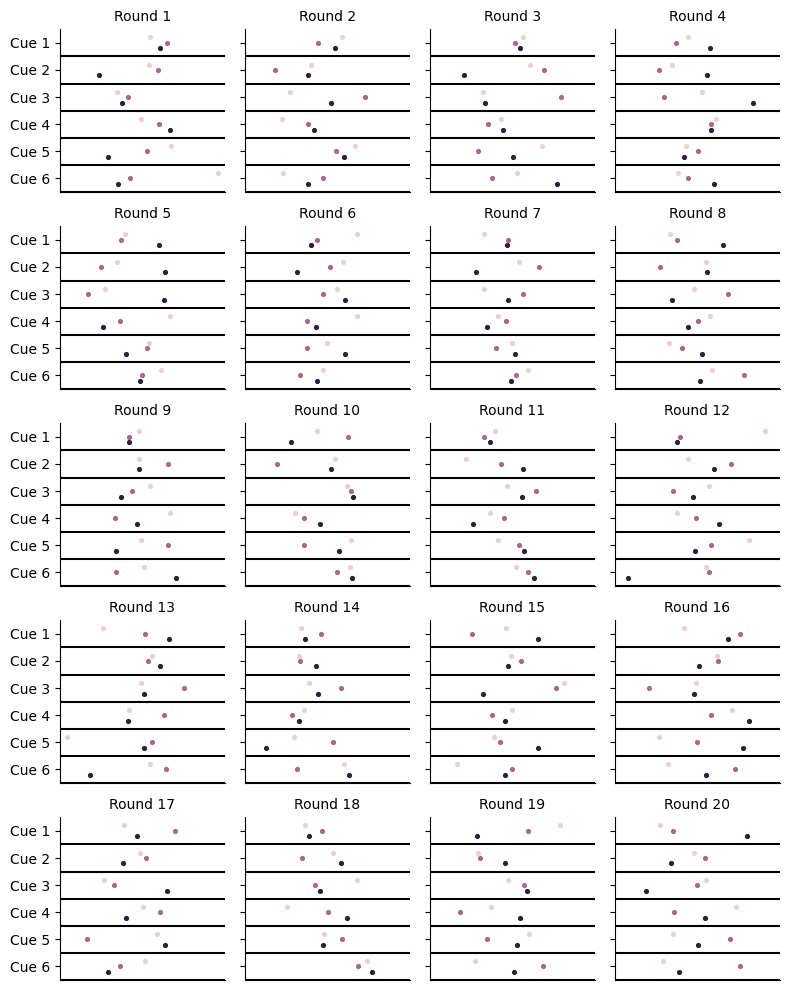

In [4]:
df_alternatives_long = df_alternatives.melt(
    id_vars=["round", "alternative"],
    value_vars=cue_columns
)
# Visualizing the attributes of the different prospects
g = sns.catplot(
    df_alternatives_long,
    y="variable",
    x="value",
    hue="alternative",
    col="round",
    col_wrap=4,
    dodge=0.4,
    kind="point",
    height=2,
    aspect=1,
    join=False,
    legend=False,
    scale=0.5,
)
for y in np.arange(0.5, 6.5, 1):
    for ax in g.axes.flat:
        ax.axhline(y, color="black")
        ax.set_xticks([])
g.set_yticklabels(["Cue 1", "Cue 2", "Cue 3", "Cue 4", "Cue 5", "Cue 6"])
g.set_xlabels("")
g.set_ylabels("")
g.set_titles("Round {col_name}")
plt.tight_layout();

#### Payoffs

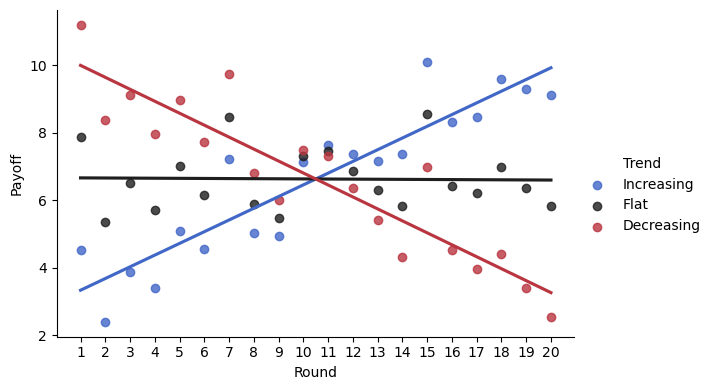

In [5]:
# fmt: off
payoffs_game = {
    "Increasing": [
        4.53, 2.40, 3.87, 3.40, 5.10, 4.57, 7.23, 5.03, 4.93, 7.13, 
        7.63, 7.37, 7.17, 7.37, 10.10, 8.33, 8.47, 9.60, 9.30, 9.13
    ],
    "Flat": [
        7.87, 5.37, 6.50, 5.70, 7.03, 6.17, 8.47, 5.90, 5.47, 7.30, 
        7.47, 6.87, 6.30, 5.83, 8.57, 6.43, 6.23, 7.00, 6.37, 5.83
    ],
    "Decreasing": [
        11.20, 8.37, 9.13, 7.97, 8.97, 7.73, 9.73, 6.80, 6.00, 7.50, 
        7.30, 6.37, 5.43, 4.33, 7.00, 4.53, 3.97, 4.40, 3.40, 2.53
    ],
}
# fmt: on

# Saving and visualizing the payoffs:
df_payoffs = pd.DataFrame(payoffs_game)
df_payoffs["Round"] = np.arange(1, 21)
df_payoffs = df_payoffs.melt(
    id_vars=["Round"], value_vars=["Increasing", "Flat", "Decreasing"],
    var_name="Trend", 
    value_name="Payoff"
)

df_payoffs.to_csv("Simulation_Payoffs_Main.csv")

g = sns.lmplot(
    x="Round",
    y="Payoff",
    data=df_payoffs,
    hue="Trend",
    aspect=1.5,
    height=4,
    palette=pal,
    ci=False,
)
g.set_ylabels("Payoff")
g.ax.set_xticks(np.arange(1, N+1));

#### Agents

In [6]:
# Number of agents of each type
N_AGENTS_EACH_TYPE = 1000

# Payoff types:
PAYOFFS_TYPES = ["Increasing", "Flat", "Decreasing"]

# Random choice probabilities:
RANDOM_CHOICE_PROBS = [0, 0.5, 1]

# Initial beliefs: Null vector.
INITIAL_BELIEFS = [0, 0, 0, 0, 0, 0]

# Agents are all possible combinations of these variables
agents_properties = product(
    PAYOFFS_TYPES,
    RANDOM_CHOICE_PROBS,
    np.arange(0, N_AGENTS_EACH_TYPE),
)
# Generating the agents
agents = [
    Agent(
        f"{payoff_type}_{random_choice_prob}_{i}",
        INITIAL_BELIEFS.copy(),
        random_choice_prob=random_choice_prob,
        payoffs_type=payoff_type,
    )
    for (payoff_type, random_choice_prob, i) in agents_properties
]

#### Initializing and Running Simulation

In [7]:
# Reshaping the alternatives in a way the simulation can process.
prospects_game = df_alternatives.set_index(["round", "alternative"])[
    cue_columns
].values.reshape(-1, J, p).astype(float)

# Setting up learning environment
learning_env_game = LearningEnvironment(payoffs=payoffs_game, prospects=prospects_game)
# Adding agents
learning_env_game.add_agents(agents)
# Simulate!
learning_env_game.simulate()

### Saving Results

In [8]:
# Recovering end beliefs from model.
df_end_beliefs = learning_env_game.get_end_beliefs()
# Recovering payoff trend and choice strategy from agent's name:
df_end_beliefs["Trend"] = df_end_beliefs.AgentName.apply(lambda x: x.split("_")[0])
df_end_beliefs["Choice_Strategy"] = df_end_beliefs.AgentName.apply(
    lambda x: x.split("_")[1]
).map({"0": "100% Positive Test", "0.5": "Mixed", "1": "100% Random"})

# Computing the strength in beliefs

df_end_beliefs["Strength_Beliefs"] = (
    df_end_beliefs[[f"Belief_{i}" for i in range(1, 7)]].abs().mean(axis=1)
)

df_end_beliefs.to_csv("Simulation_Results_Main.csv")

## Robustness Check

### Setup

#### Different Alternatives and Cues

In [9]:
J = 5 # More alternatives
N = 15 # Fewer rounds
p = 10 # More cues


# Seed for reproducibility
np.random.seed(28390312)

# Generating random prospects:
cue_values = np.random.normal(0, 1, size=(J*N, p)) # Random cue values

# Storing them into a dataset
round_numbers = np.repeat(np.arange(1, N+1), J).reshape(-1, 1)
alternatives = np.tile(np.arange(1, J+1), N).reshape(-1, 1)
cue_columns = [f"cue_{i}" for i in range(1, p+1)]
df_alternatives = pd.DataFrame(np.hstack([round_numbers, alternatives, cue_values]),
                              columns=["round", "alternative"] + cue_columns)
df_alternatives["round"] = df_alternatives["round"].astype(int)
df_alternatives["alternative"] = df_alternatives["alternative"].astype(int)

#### Different payoffs

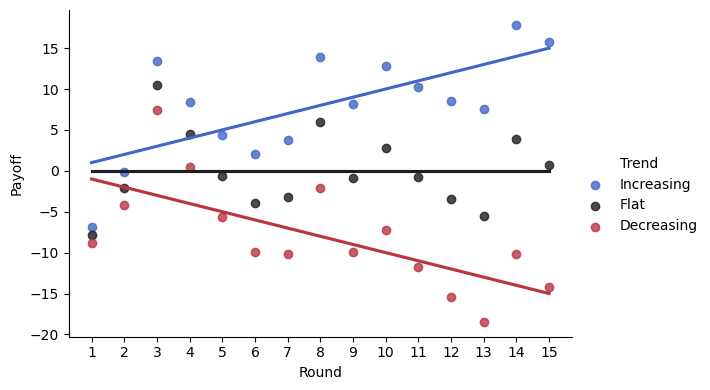

In [10]:
flat = detrend(np.random.normal(0, 4, size=N))
increasing = flat + np.arange(1, N+1)
decreasing = flat - np.arange(1, N+1)
payoffs_game = {
    "Increasing": increasing,
    "Flat": flat,
    "Decreasing": decreasing
}

# Visualizing the payoffs:
df_payoffs = pd.DataFrame(payoffs_game)
df_payoffs["Round"] = np.arange(1, N+1)
df_payoffs = df_payoffs.melt(
    id_vars=["Round"], value_vars=["Increasing", "Flat", "Decreasing"],
    var_name="Trend", 
    value_name="Payoff"
)

df_payoffs.to_csv("Simulation_Payoffs_RobustnessCheck.csv")

g = sns.lmplot(
    x="Round",
    y="Payoff",
    data=df_payoffs,
    hue="Trend",
    aspect=1.5,
    height=4,
    palette=pal,
    ci=False,
)
g.set_ylabels("Payoff")
g.ax.set_xticks(np.arange(1, N+1));

#### Agents

In [11]:
# Number of agents of each type
N_AGENTS_EACH_TYPE = 1000

# Payoff types:
PAYOFFS_TYPES = ["Increasing", "Flat", "Decreasing"]

# Random choice probabilities:
RANDOM_CHOICE_PROBS = [0, 0.5, 1]

# Agents are all possible combinations of these variables
agents_properties = product(
    PAYOFFS_TYPES,
    RANDOM_CHOICE_PROBS,
    np.arange(0, N_AGENTS_EACH_TYPE),
)
# Generating the agents, with random starting beliefs
agents = [
    Agent(
        f"{payoff_type}_{random_choice_prob}_{i}",
        np.random.normal(0, 1, size=p),
        random_choice_prob=random_choice_prob,
        payoffs_type=payoff_type,
    )
    for (payoff_type, random_choice_prob, i) in agents_properties
]

#### Initializing and Running Simulation

In [12]:
# Reshaping the alternatives in a way the simulation can process.
prospects_game = df_alternatives.set_index(["round", "alternative"])[
    cue_columns
].values.reshape(-1, J, p).astype(float)

# Setting up learning environment
learning_env_game = LearningEnvironment(payoffs=payoffs_game, prospects=prospects_game)
# Adding agents
learning_env_game.add_agents(agents)
# Simulate!
learning_env_game.simulate()

### Saving Results

In [13]:
# Recovering end beliefs from model.
df_end_beliefs = learning_env_game.get_end_beliefs()
# Recovering payoff trend and choice strategy from agent's name:
df_end_beliefs["Trend"] = df_end_beliefs.AgentName.apply(lambda x: x.split("_")[0])
df_end_beliefs["Choice_Strategy"] = df_end_beliefs.AgentName.apply(
    lambda x: x.split("_")[1]
).map({"0": "100% Positive Test", "0.5": "Mixed", "1": "100% Random"})

# Computing the strength in beliefs

df_end_beliefs["Strength_Beliefs"] = (
    df_end_beliefs[[f"Belief_{i}" for i in range(1, 7)]].abs().mean(axis=1)
)

df_end_beliefs.to_csv("Simulation_Results_RobustnessCheck.csv")